# La cooperación no decae al azar — decae cada vez más rápido

**47.931 pagos. 7.108 personas. 5 años.** Cada vez que un grupo termina un préstamo y empieza otro, la cooperación rebota — y la siguiente caída es más empinada que la anterior.

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-22-punctuated-decline-cooperation/notebook.ipynb)

**Paper:** [Punctuated decline of human cooperation](https://doi.org/10.1038/s41586-026-10380-3) · *Nature*, 22 abril 2026

**Video:** [Pendiente]


## Qué pasó aquí

Un equipo siguió durante 5 años a 7.108 personas en Sierra Leona que tomaron microcréditos en grupo (joint-liability: si el grupo no paga, *todos* pierden el acceso al crédito). Eso convierte el préstamo en un dilema social — cada miembro tiene incentivo para escaquearse, pero si todos lo hacen, el grupo se hunde.

Lo que rastrearon es **cuánto coopera la gente**, semana a semana, ronda tras ronda, ciclo tras ciclo. Y encontraron un patrón que no encaja con las teorías racionales clásicas.


In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_DATOS = '#2563EB'        # azul CaM
COLOR_ALERTA = '#DC2626'       # rojo (anomalía / extremo)
COLOR_REFERENCIA = '#D97706'   # ámbar (umbral / línea base)
COLOR_SECUNDARIO = '#059669'   # verde (segunda variable)
FUENTE = 'Fuente: Sabin et al. (2026), Nature | Datos: Source Data MOESM4-MOESM10'

# ══════════════════════════════════════════════════════════════
# Imports + estilo
# ══════════════════════════════════════════════════════════════
import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'

# Estilo CaM (local primero, GitHub fallback)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# ══════════════════════════════════════════════════════════════
# Descarga datos (si no existen localmente)
# ══════════════════════════════════════════════════════════════
os.makedirs('datos', exist_ok=True)
SLUG = '2026-04-22-punctuated-decline-cooperation'
for f in ['decline_por_ciclo.csv', 'restart_z_scores.csv',
          'motivaciones.csv', 'demografia_entrevistados.csv']:
    local = f'datos/{f}'
    if not os.path.exists(local):
        urllib.request.urlretrieve(f'{BASE}/papers/{SLUG}/datos/{f}', local)

# ══════════════════════════════════════════════════════════════
# Carga
# ══════════════════════════════════════════════════════════════
decline = pd.read_csv('datos/decline_por_ciclo.csv')
restart = pd.read_csv('datos/restart_z_scores.csv')
motiv = pd.read_csv('datos/motivaciones.csv')
demo = pd.read_csv('datos/demografia_entrevistados.csv')

print(f'Decline por ciclo: {len(decline)} filas ({decline.ciclo.nunique()} ciclos × {decline["round"].nunique()} rondas)')
print(f'Restart z-scores:  {len(restart)} filas ({restart.restart_numero.nunique()} reinicios × pre/post)')
print(f'Motivaciones:      {motiv.n_clientes.sum()} menciones (denominador n=128 — múltiples motivaciones por entrevistado posibles)')
print(f'Demografía:        {demo[demo.categoria=="genero"].n.sum()} clientes entrevistados')


Decline por ciclo: 30 filas (5 ciclos × 6 rondas)
Restart z-scores:  8 filas (4 reinicios × pre/post)
Motivaciones:      180 menciones (denominador n=128 — múltiples motivaciones por entrevistado posibles)
Demografía:        64 clientes entrevistados


## Aquí está.


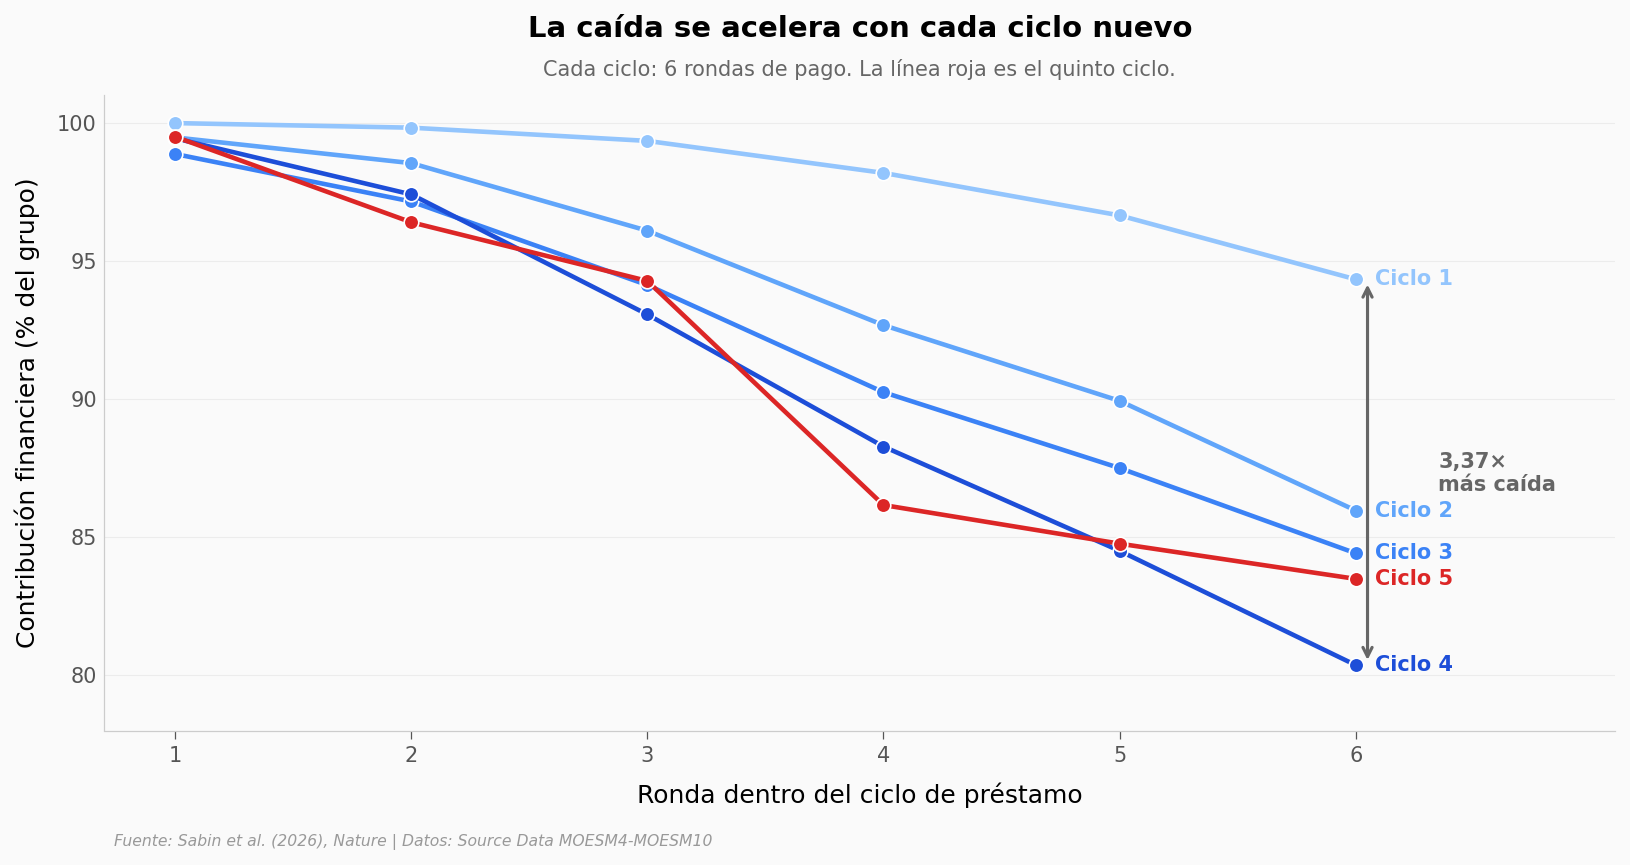

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Una curva por ciclo — gradiente de azul a rojo (más oscuro = ciclo más reciente)
colores = ['#93C5FD', '#60A5FA', '#3B82F6', '#1D4ED8', '#DC2626']

for i, ciclo in enumerate(sorted(decline.ciclo.unique())):
    sub = decline[decline.ciclo == ciclo].sort_values('round')
    ax.plot(sub['round'], sub.contribucion_financiera_pct,
            marker='o', markersize=7, linewidth=2.2,
            color=colores[i], zorder=5,
            markeredgecolor='white', markeredgewidth=0.8)
    # Inline label al final de la curva
    final = sub.iloc[-1]
    ax.text(final['round'] + 0.08, final.contribucion_financiera_pct,
            f'Ciclo {ciclo}', fontsize=10, fontweight='bold',
            color=colores[i], va='center')

# Anotación clave: la caída del ciclo 4 vs ciclo 1
ax.annotate('', xy=(6.05, 80.4), xytext=(6.05, 94.3),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(6.35, 87.3, '3,37×\nmás caída', fontsize=10, fontweight='bold',
        color='#666666', va='center', ha='left')

ax.set_xlabel('Ronda dentro del ciclo de préstamo')
ax.set_ylabel('Contribución financiera (% del grupo)')
ax.set_title('La caída se acelera con cada ciclo nuevo',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada ciclo: 6 rondas de pago. La línea roja es el quinto ciclo.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xticks(range(1, 7))
ax.set_xlim(0.7, 7.1)
ax.set_ylim(78, 101)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/decline_por_ciclo.png', dpi=200, bbox_inches='tight')
plt.show()


La aceleración salta a la vista. El ciclo 1 termina en 94,3% — la gente sigue cumpliendo casi todo. El ciclo 4 termina en 80,4%, una caída 3,37 veces mayor en el mismo número de rondas. Y los grupos que llegan al ciclo 4 son los más cumplidores (los demás ya se quedaron por el camino).

Esto es lo incómodo: si la cooperación cayera por aprendizaje racional ("ya entendí cómo funciona, voy a escaquearme menos"), debería estabilizarse o incluso subir. Pasa lo contrario.


## El esfuerzo cooperativo se desploma todavía más rápido

El paper distingue dos métricas: la **contribución financiera** (cuánto pagas) y el **esfuerzo cooperativo** (qué tanto ayudas al grupo a cumplir, recordándole, cubriendo a quien no llegó, etc.). El segundo es más blando, más opcional — y más sensible.


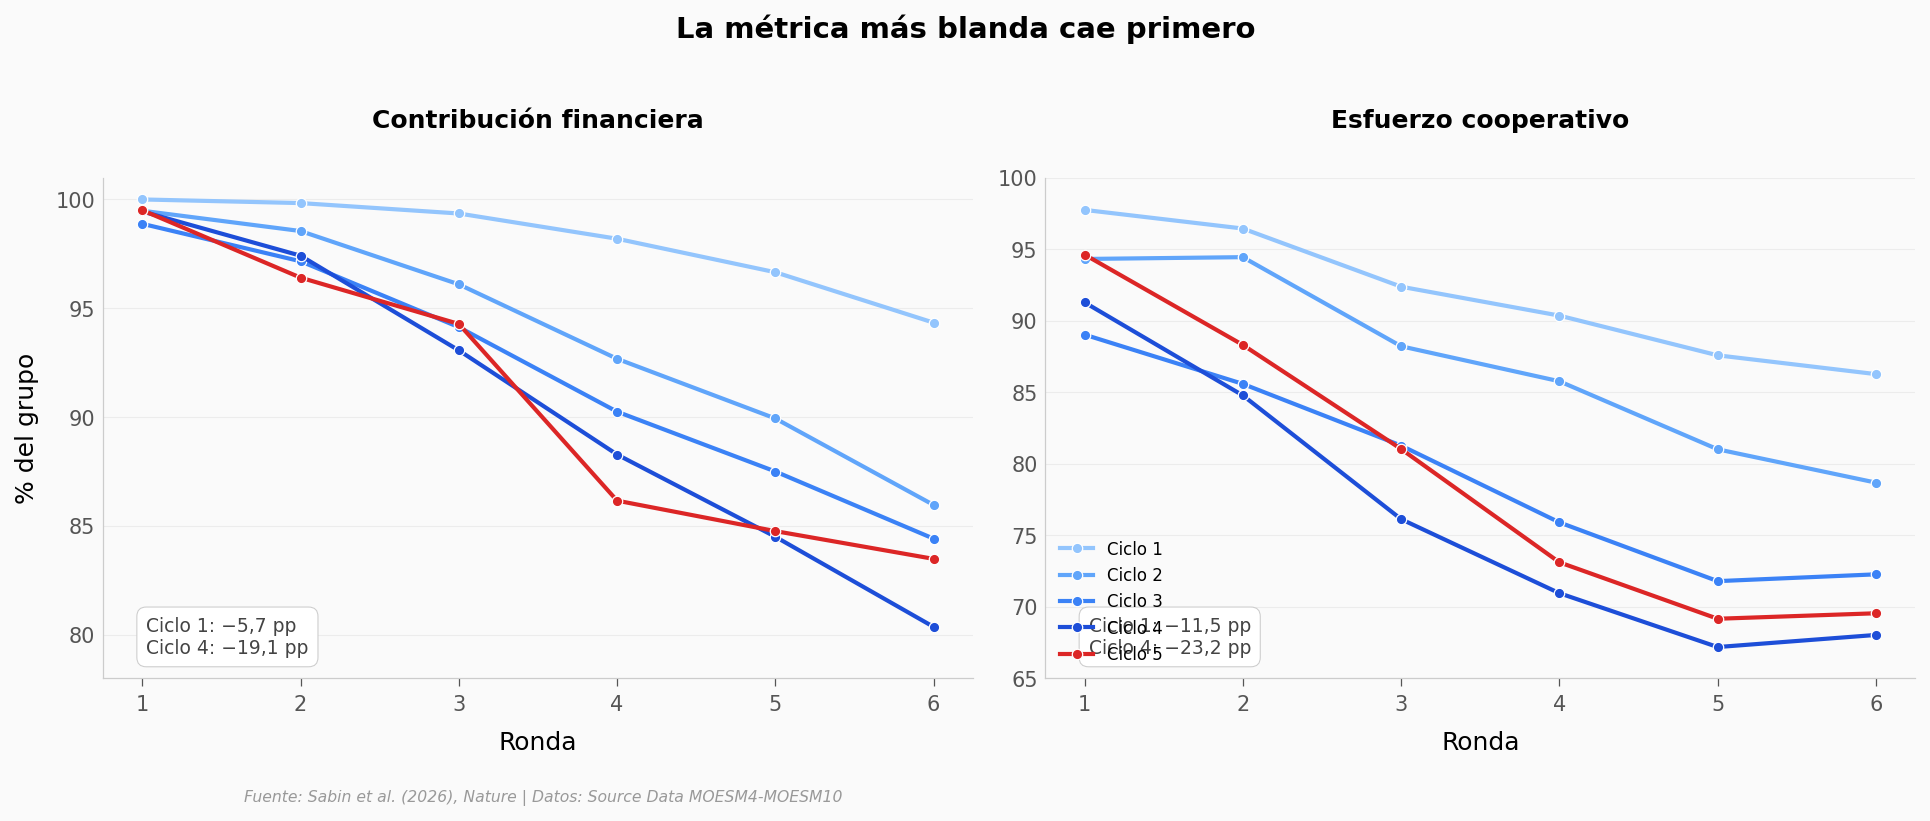

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

colores = ['#93C5FD', '#60A5FA', '#3B82F6', '#1D4ED8', '#DC2626']

for ax, col, titulo in [
    (ax1, 'contribucion_financiera_pct', 'Contribución financiera'),
    (ax2, 'esfuerzo_cooperativo_pct', 'Esfuerzo cooperativo'),
]:
    for i, ciclo in enumerate(sorted(decline.ciclo.unique())):
        sub = decline[decline.ciclo == ciclo].sort_values('round')
        ax.plot(sub['round'], sub[col], marker='o', markersize=5,
                linewidth=2, color=colores[i], zorder=5,
                markeredgecolor='white', markeredgewidth=0.6,
                label=f'Ciclo {ciclo}')
    ax.set_xlabel('Ronda')
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xticks(range(1, 7))

ax1.set_ylabel('% del grupo')
ax1.set_ylim(78, 101)
ax2.set_ylim(65, 100)
ax2.legend(fontsize=8, loc='lower left', framealpha=0.85, ncol=1)

# Anotaciones de caída en cada panel (ciclo 1 vs ciclo 4)
ax1.text(0.05, 0.05, 'Ciclo 1: −5,7 pp\nCiclo 4: −19,1 pp',
         transform=ax1.transAxes, fontsize=9, color='#444444',
         bbox=dict(facecolor='white', edgecolor='#CCCCCC', boxstyle='round,pad=0.5'))
ax2.text(0.05, 0.05, 'Ciclo 1: −11,5 pp\nCiclo 4: −23,2 pp',
         transform=ax2.transAxes, fontsize=9, color='#444444',
         bbox=dict(facecolor='white', edgecolor='#CCCCCC', boxstyle='round,pad=0.5'))

plt.suptitle('La métrica más blanda cae primero', fontsize=14, fontweight='bold', y=1.02)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/financiera_vs_esfuerzo.png', dpi=200, bbox_inches='tight')
plt.show()


## ¿Qué pasa cuando vuelve a empezar el préstamo?

Cuando un ciclo termina y arranca el siguiente, los miembros casi no cambian — el dilema sigue siendo el mismo. Pero algo se "resetea" en su comportamiento. El paper midió ese rebote en z-scores (cuántas desviaciones estándar arriba o abajo del promedio histórico).


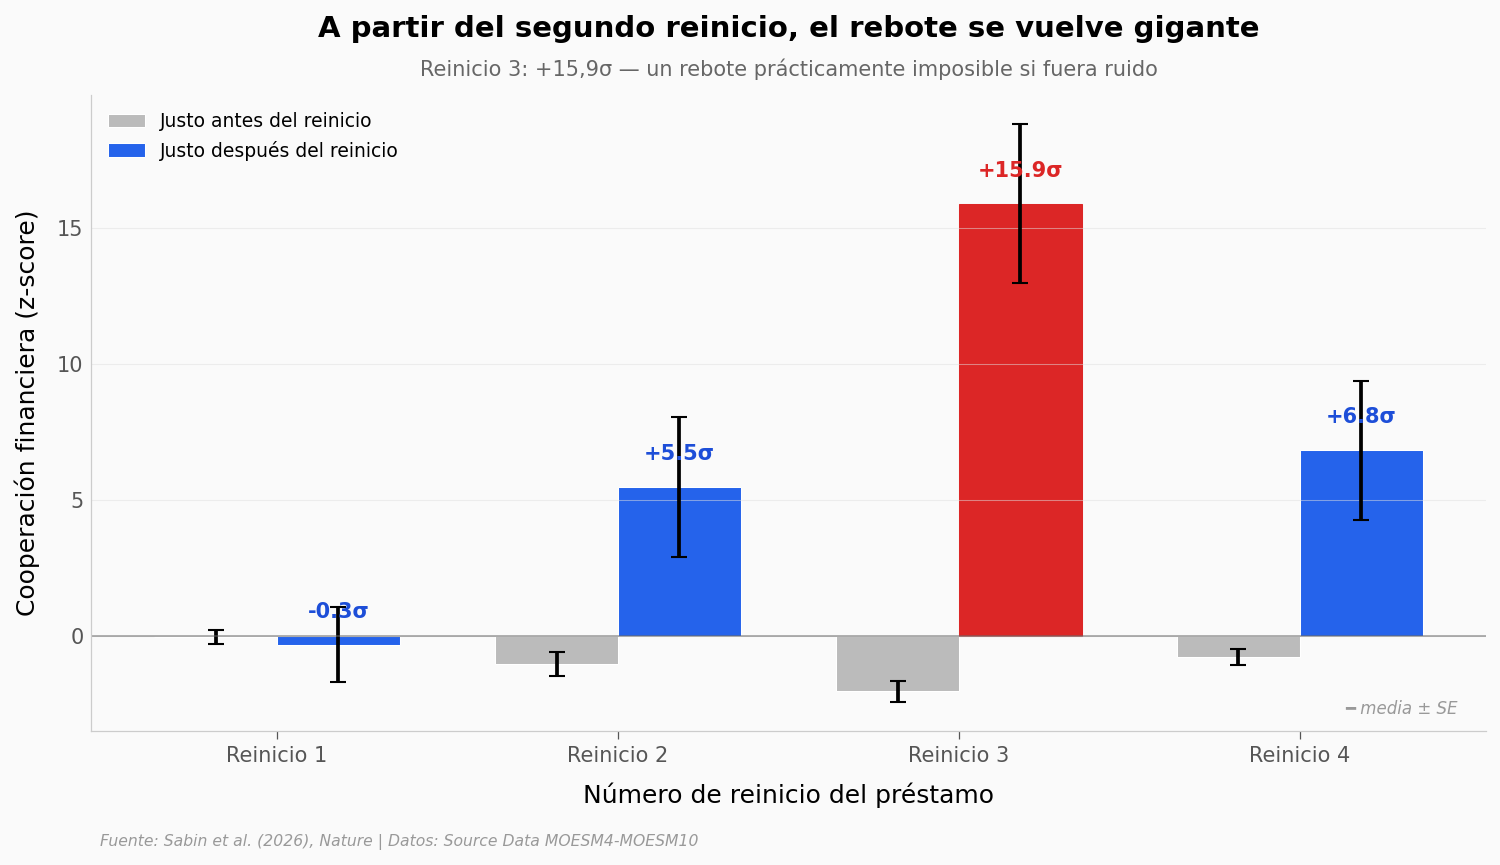

In [4]:
fig, ax = plt.subplots(figsize=(12, 5.5))

restarts = sorted(restart.restart_numero.unique())
x = np.arange(len(restarts))
width = 0.36

# Pre vs post para financiero
pre_fin = [restart[(restart.restart_numero==r) & (restart.momento=='pre_restart')].financiero_z.values[0] for r in restarts]
post_fin = [restart[(restart.restart_numero==r) & (restart.momento=='post_restart')].financiero_z.values[0] for r in restarts]
pre_se = [restart[(restart.restart_numero==r) & (restart.momento=='pre_restart')].financiero_se.values[0] for r in restarts]
post_se = [restart[(restart.restart_numero==r) & (restart.momento=='post_restart')].financiero_se.values[0] for r in restarts]

bars1 = ax.bar(x - width/2, pre_fin, width, yerr=pre_se,
               color='#BBBBBB', edgecolor='white', linewidth=0.5,
               capsize=4, label='Justo antes del reinicio')
bars2 = ax.bar(x + width/2, post_fin, width, yerr=post_se,
               color='#2563EB', edgecolor='white', linewidth=0.5,
               capsize=4, label='Justo después del reinicio')

# Resaltar restart 3 post
bars2[2].set_color('#DC2626')

# Etiquetas encima de barras post
for i, v in enumerate(post_fin):
    ax.text(i + width/2, v + 1.0, f'+{v:.1f}σ' if v > 0 else f'{v:.1f}σ',
            ha='center', fontsize=10, fontweight='bold',
            color='#DC2626' if i == 2 else '#1D4ED8')

ax.axhline(y=0, color='#666666', linewidth=0.8, linestyle='-', alpha=0.6)
ax.set_xlabel('Número de reinicio del préstamo')
ax.set_ylabel('Cooperación financiera (z-score)')
ax.set_title('A partir del segundo reinicio, el rebote se vuelve gigante',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Reinicio 3: +15,9σ — un rebote prácticamente imposible si fuera ruido',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xticks(x)
ax.set_xticklabels([f'Reinicio {r}' for r in restarts])
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)

ax.text(0.98, 0.02, '━ media ± SE',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/restart_jumps.png', dpi=200, bbox_inches='tight')
plt.show()


## ¿Cómo de raro es ese +15,9σ?

Cuando todas las observaciones de cooperación se ponen en el mismo eje (z-scores), el rebote del reinicio 3 sobresale tanto que vale la pena verlo en una distribución.


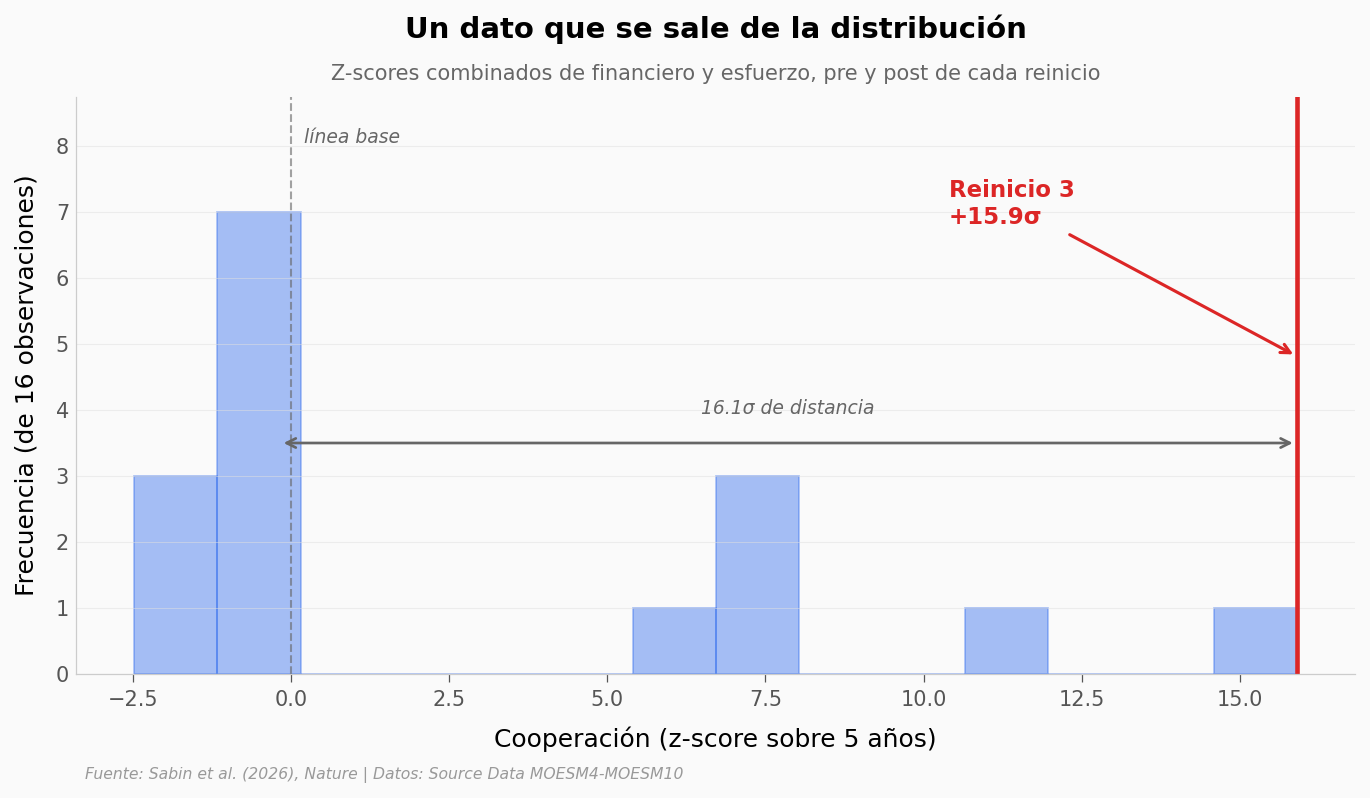

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))

# Todos los z-scores de la tabla restart (financiero + esfuerzo, pre + post = 16 valores)
todos_z = pd.concat([restart.financiero_z, restart.esfuerzo_z]).values
n, bins, patches = ax.hist(todos_z, bins=14, color=COLOR_DATOS, alpha=0.4,
                            edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.25
ax.set_ylim(0, y_max)

# Línea de referencia (cero = sin desviación del promedio histórico)
ax.axvline(x=0, color='#666666', linewidth=1.0, linestyle='--', alpha=0.6)
ax.text(0.2, y_max*0.92, 'línea base', fontsize=9, color='#666666', style='italic')

# Restart 3 financiero (+15,90σ) — el extremo
restart_3_fin = restart[(restart.restart_numero==3) & (restart.momento=='post_restart')].financiero_z.values[0]
ax.axvline(x=restart_3_fin, color=COLOR_ALERTA, linewidth=2.2)
ax.annotate(f'Reinicio 3\n+{restart_3_fin:.1f}σ',
            xy=(restart_3_fin, y_max*0.55), xytext=(restart_3_fin - 5.5, y_max*0.78),
            fontsize=11, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

# Flecha bidireccional desde la mediana hasta el extremo
mediana = np.median(todos_z)
ax.annotate('', xy=(restart_3_fin, y_max*0.4), xytext=(mediana, y_max*0.4),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.3))
ax.text((mediana + restart_3_fin)/2, y_max*0.45,
        f'{restart_3_fin - mediana:.1f}σ de distancia',
        fontsize=9, color='#666666', ha='center', style='italic')

ax.set_xlabel('Cooperación (z-score sobre 5 años)')
ax.set_ylabel('Frecuencia (de 16 observaciones)')
ax.set_title('Un dato que se sale de la distribución',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Z-scores combinados de financiero y esfuerzo, pre y post de cada reinicio',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_anomalia.png', dpi=200, bbox_inches='tight')
plt.show()


## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|:-----------:|---------|
| 47.931 pagos de 7.108 prestatarios en 5 años | ✅ | Reportado literal en abstract; el paper lo sustenta con la base de datos del prestamista |
| Ciclo 4 cae 3,37× más rápido que ciclo 1 (en pp) | ✅ | Cálculo directo del CSV: −19,07 pp / −5,66 pp = 3,37 |
| Reinicio 3 financiero rebota +15,9σ post-restart | ✅ | Valor del MOESM10 panel_a; SE = 2,93 → es ~5,4× su error estándar |
| Motivación económica solo 17,2% (la menos mencionada) | ✅ | 22 de 128 respuestas — el paper lo enmarca como evidencia contra la teoría racional |
| El patrón refleja desviaciones del comportamiento racional | ⚠️ | El paper lo plantea como afirmación principal (verbo *show*); el diseño es observacional, así que muestra el patrón pero no descarta otras explicaciones |

> **Limitaciones honestas:**
> - **Atrición fuerte:** de 1.026 grupos al ciclo 1, solo 197 llegan al ciclo 4 (−81%). Los grupos que persisten son los más cumplidores, así que el dato del ciclo 4 *subestima* la caída real de la población inicial.
> - **Diseño observacional:** los datos muestran el patrón temporal, no su causa. La interpretación "comportamiento no racional" es la que defiende el paper, pero no se descartan factores como fatiga, cambios económicos en Sierra Leona o efectos del prestamista.
> - **Submuestra de motivaciones:** 64 entrevistados (92,2% mujeres) sobre 7.108 prestatarios. Indicativo, no representativo.


## Ahora tú

Los datos están en `datos/`. Tres preguntas para explorar:

**1. ¿La aceleración aplica también al esfuerzo cooperativo, o solo a la contribución financiera?**
Pista: calcula `caida = decline.groupby('ciclo').apply(lambda g: g.iloc[0] - g.iloc[-1])` para ambas columnas y compara.

**2. ¿Qué motivación domina si excluimos las dos más reportadas?**
Pista: ordena `motiv` por `n_clientes` y mira las posiciones 3-4.

**3. ¿El segundo reinicio ya muestra el rebote gigante, o solo el tercero?**
Pista: filtra `restart` por `momento == 'post_restart'` y compara `financiero_z` entre `restart_numero == 2` y `restart_numero == 3`.


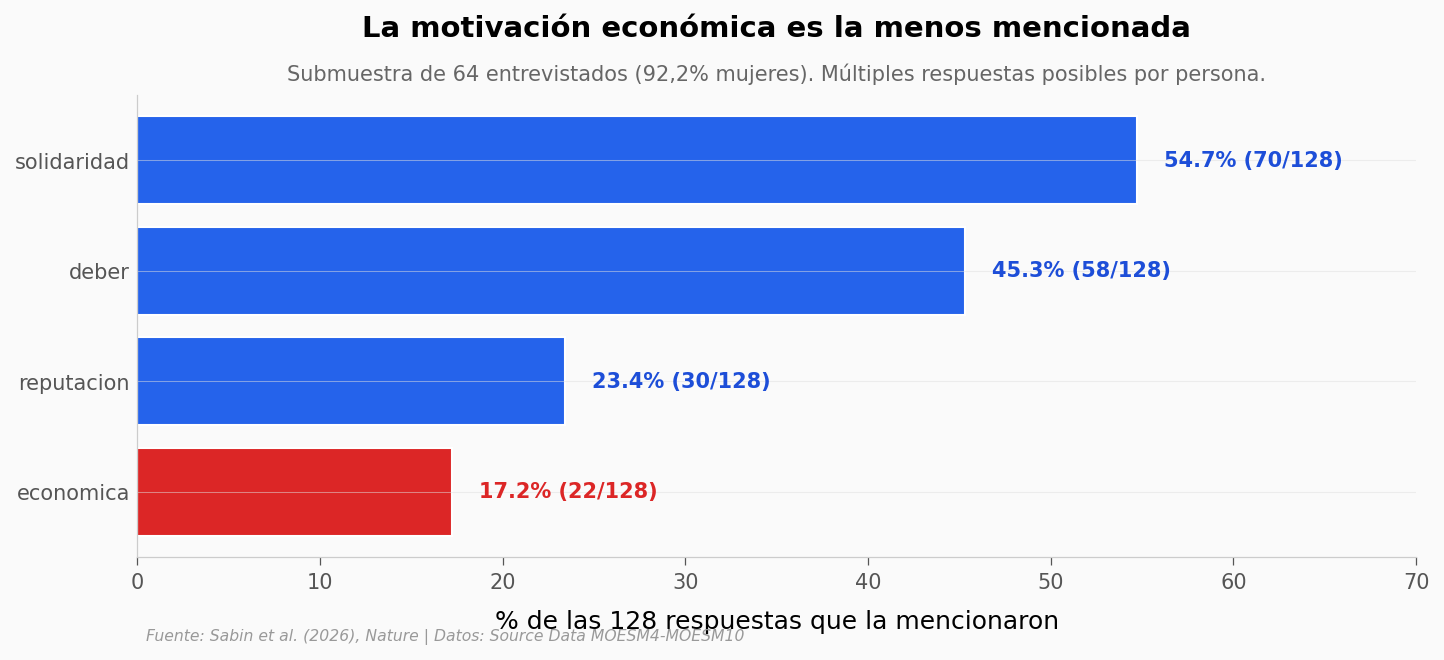

Las dos motivaciones que dominan (solidaridad, deber) son sociales/morales.
La que la teoría racional clásica predice como dominante (la económica) es la menor.


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 2: motivaciones reportadas en orden, con la económica resaltada
fig, ax = plt.subplots(figsize=(11, 4))

motiv_sorted = motiv.sort_values('pct')
colores_motiv = ['#DC2626' if m == 'economica' else '#2563EB' for m in motiv_sorted.motivacion]

bars = ax.barh(motiv_sorted.motivacion, motiv_sorted.pct,
               color=colores_motiv, edgecolor='white', linewidth=1.0)

for i, (pct, n) in enumerate(zip(motiv_sorted.pct, motiv_sorted.n_clientes)):
    ax.text(pct + 1.5, i, f'{pct}% ({n}/128)',
            va='center', fontsize=10, fontweight='bold',
            color='#DC2626' if motiv_sorted.motivacion.iloc[i] == 'economica' else '#1D4ED8')

ax.set_xlabel('% de las 128 respuestas que la mencionaron')
ax.set_title('La motivación económica es la menos mencionada',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Submuestra de 64 entrevistados (92,2% mujeres). Múltiples respuestas posibles por persona.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(0, 70)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/motivaciones.png', dpi=200, bbox_inches='tight')
plt.show()

print('Las dos motivaciones que dominan (solidaridad, deber) son sociales/morales.')
print('La que la teoría racional clásica predice como dominante (la económica) es la menor.')


---

## Fuentes

**Paper**: [Punctuated decline of human cooperation](https://doi.org/10.1038/s41586-026-10380-3)  
*Nature, 2026-04-22*

**Source Data**: [Source Data files MOESM4-MOESM10 (figure data XLSX)](https://www.nature.com/articles/s41586-026-10380-3#Sec27)  
*Tablas oficiales que acompañan el paper (mismo DOI)*

**Dataset canónico**: [Deidentified group lending data and replication code](https://doi.org/10.17605/OSF.IO/26BFC)  
*Datos brutos en OSF (no descargados aquí — Source Data fue suficiente)*

*19 afirmaciones verificadas contra estas fuentes*
